In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Хід роботи

1. ##### Завантаження та попередня обробка даних



Викачаємо датасет Titanic із Kaggle. Завантажимо файл train.csv у DataFrame.
Виведемо загальну інформацію про дані, перевіримо наявність пропущених значень.

In [85]:
df_original = pd.read_csv("titanic/train.csv")
df_from_csv = df_original.copy()
print(df_from_csv.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

Перевіримо відсутні значення

In [86]:
print("Кількість відсутніх значень у стовбці:")
print(df_from_csv.isnull().sum())


Кількість відсутніх значень у стовбці:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


* Age - numerical continuous
* Cabin - categorical nominal
* Embarked - categorical nominal

Стовбець Cabin містить занадто велику кількість відсутніх значень, тому його краще прибрати. Також колонки PassengerId, Name та Ticket варто прибрати, оскільки вони не є інформативними.

In [87]:
df_updated = df_from_csv.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])
print(df_updated.head(10))

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S
5         0       3    male   NaN      0      0   8.4583        Q
6         0       1    male  54.0      0      0  51.8625        S
7         0       3    male   2.0      3      1  21.0750        S
8         1       3  female  27.0      0      2  11.1333        S
9         1       2  female  14.0      1      0  30.0708        C


In [88]:
df_filled = df_updated.copy()
df_filled['Age'] = df_filled['Age'].fillna(df_filled['Age'].mean())
df_filled['Embarked'] = df_filled['Embarked'].fillna(df_filled['Embarked'].mode()[0])

In [89]:
print(df_filled.head(10))

   Survived  Pclass     Sex        Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.000000      1      0   7.2500        S
1         1       1  female  38.000000      1      0  71.2833        C
2         1       3  female  26.000000      0      0   7.9250        S
3         1       1  female  35.000000      1      0  53.1000        S
4         0       3    male  35.000000      0      0   8.0500        S
5         0       3    male  29.699118      0      0   8.4583        Q
6         0       1    male  54.000000      0      0  51.8625        S
7         0       3    male   2.000000      3      1  21.0750        S
8         1       3  female  27.000000      0      2  11.1333        S
9         1       2  female  14.000000      1      0  30.0708        C


Перевіримо чи немає відсутніх значень після заповнення

In [90]:
print("Кількість відсутніх значень у стовбці:")
print(df_filled.isnull().sum())

Кількість відсутніх значень у стовбці:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


Перетворимо категоріальні ознаки (Sex та Embarked) у числовий формат

In [91]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = ['Sex', 'Embarked']
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df_filled[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded,
                          columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df_filled, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)


In [92]:
print(f"Encoded Employee data : \n{df_encoded.head(10)}")

Encoded Employee data : 
   Survived  Pclass        Age  SibSp  Parch     Fare  Sex_female  Sex_male  \
0         0       3  22.000000      1      0   7.2500         0.0       1.0   
1         1       1  38.000000      1      0  71.2833         1.0       0.0   
2         1       3  26.000000      0      0   7.9250         1.0       0.0   
3         1       1  35.000000      1      0  53.1000         1.0       0.0   
4         0       3  35.000000      0      0   8.0500         0.0       1.0   
5         0       3  29.699118      0      0   8.4583         0.0       1.0   
6         0       1  54.000000      0      0  51.8625         0.0       1.0   
7         0       3   2.000000      3      1  21.0750         0.0       1.0   
8         1       3  27.000000      0      2  11.1333         1.0       0.0   
9         1       2  14.000000      1      0  30.0708         1.0       0.0   

   Embarked_C  Embarked_Q  Embarked_S  
0         0.0         0.0         1.0  
1         1.0         0.0

2. ##### Поділ даних на навчальну та тестову вибірки

Виконаємо поділ даних на train/test та виведемо розміри навчальної та тестової вибірок.

In [93]:
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']
feature_names = df_encoded.columns.tolist()
feature_names.remove('Survived')
target_names=['Not survived','Survived']


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Розподіл даних:")
print(f"   Навчальна вибірка: {X_train.shape[0]} зразків")
print(f"   Тестова вибірка:  {X_test.shape[0]} зразків")
print()


Розподіл даних:
   Навчальна вибірка: 623 зразків
   Тестова вибірка:  268 зразків



3. ##### Побудова класифікатора на основі дерев рішень

* Навчимо модель дерева рішень на навчальних даних
* Отримаємо класифікацію для тестової вибірки
* Проаналізуємо глибину дерева та кількість вузлів



In [95]:
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

dt_classifier.fit(X_train, y_train)

y_pred = dt_classifier.predict(X_test)


depth = dt_classifier.get_depth()
print(f"Глибина дерева: {depth}")

n_nodes = dt_classifier.tree_.node_count
print(f"Загальна кількість вузлів: {n_nodes}")

Глибина дерева: 3
Загальна кількість вузлів: 15


4. ##### Оцінювання якості класифікації

Обчислимо основні метрики класифікації:
* Accuracy
* Precision
* Recall
* F1-score


In [96]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [97]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

Accuracy: 0.795
Precision: 0.864
Recall: 0.553
F1-Score: 0.675


Побудуємо confusion matrix

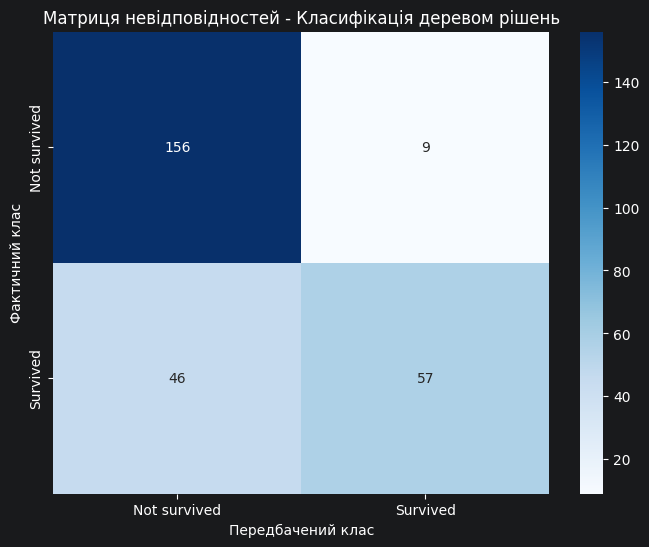

In [98]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Матриця невідповідностей - Класифікація деревом рішень')
plt.xlabel('Передбачений клас')
plt.ylabel('Фактичний клас')
plt.show()

Виведемо детальний звіт класифікації (classification_report)


In [99]:
print("Класифікаційний звіт:")
print(classification_report(y_test, y_pred, target_names=target_names))

Класифікаційний звіт:
              precision    recall  f1-score   support

Not survived       0.77      0.95      0.85       165
    Survived       0.86      0.55      0.67       103

    accuracy                           0.79       268
   macro avg       0.82      0.75      0.76       268
weighted avg       0.81      0.79      0.78       268



Проаналізуємо баланс класів та пояснимо, які метрики є більш інформативними для цього завдання.



Аналіз важливості ознак:
----------------------------------------
Pclass              : 0.189
Age                 : 0.096
SibSp               : 0.000
Parch               : 0.000
Fare                : 0.059
Sex_female          : 0.656
Sex_male            : 0.000
Embarked_C          : 0.000
Embarked_Q          : 0.000
Embarked_S          : 0.000


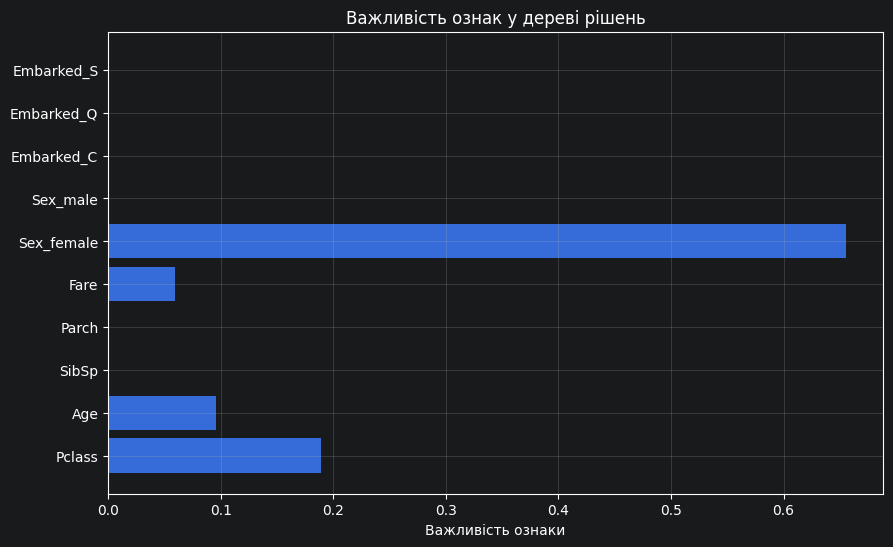


Найважливіша ознака: Sex_female


In [100]:
print("\nАналіз важливості ознак:")
print("-" * 40)
feature_importance = dt_classifier.feature_importances_
for i, (feature, importance) in enumerate(zip(feature_names, feature_importance)):
    print(f"{feature:20}: {importance:.3f}")

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel('Важливість ознаки')
plt.title('Важливість ознак у дереві рішень')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nНайважливіша ознака: {feature_names[np.argmax(feature_importance)]}")

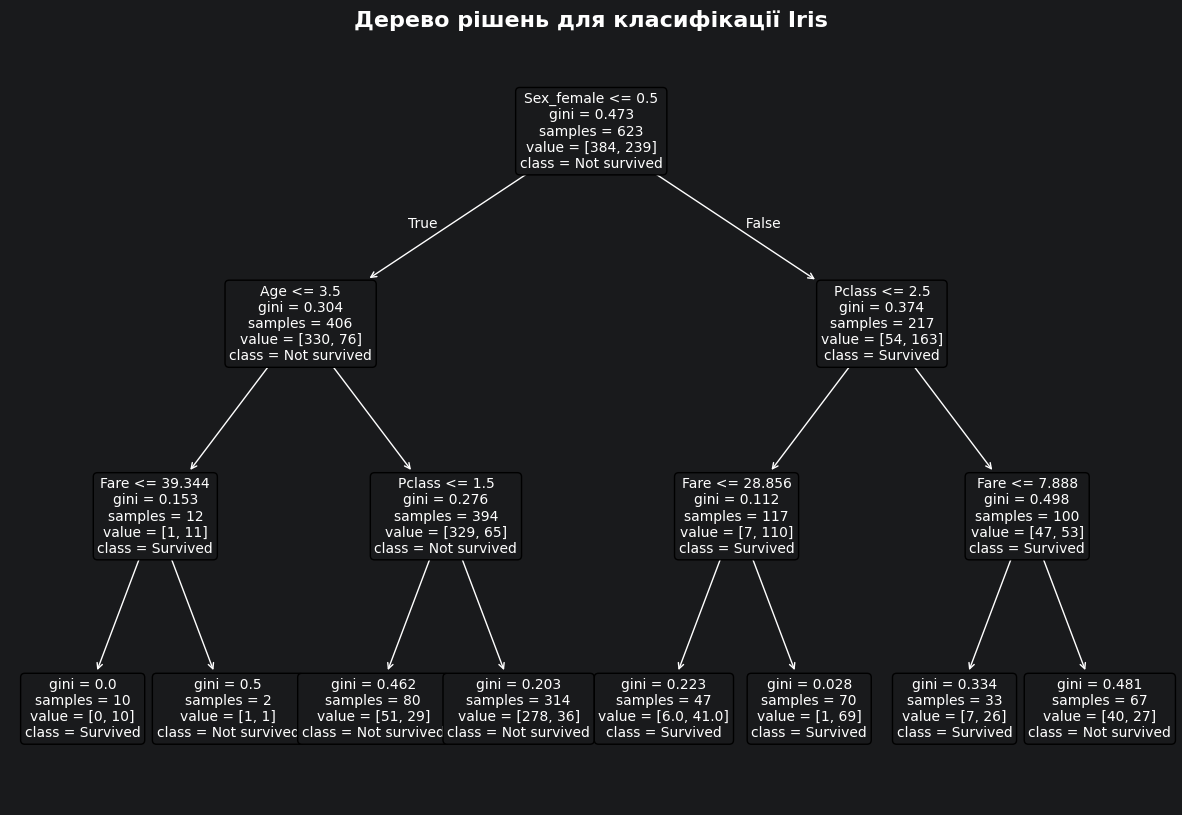

In [104]:
plt.figure(figsize=(15, 10))
plot_tree(dt_classifier,
          feature_names=feature_names,
          class_names=target_names,
          # filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево рішень для класифікації Iris", fontsize=16, fontweight='bold')
plt.show()
